# SMAT segment-removal ablation analysis

This notebook compares frozen-model removal by learned attention (`most_important`), random removal, low-attention removal (`least_important`), and the segment-length controls (`longest` and `shortest`). It covers the main automation experiment and all six coordination campaigns.

The 0% point comes from the unablated MIL predictions; no model is trained or modified here.

In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pipeline.py").is_file() and (candidate / "results").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the SMAT repository root")


ROOT = find_repo_root(Path.cwd().resolve())
RESULTS_DIR = ROOT / "results"
OUTPUT_DIR = RESULTS_DIR / "analysis" / "combined_50_100_original_styling"

EXPERIMENTS = [
    {"name": "iran_201901_X", "task": "coordination", "dataset": "infoOps", "experiments": ["iran_201901_X"]},
    {"name": "iran_201906_1", "task": "coordination", "dataset": "infoOps", "experiments": ["iran_201906_1"]},
    {"name": "china_082019_1", "task": "coordination", "dataset": "infoOps", "experiments": ["china_082019_1"]},
    {"name": "CNHU_0621_YYYY", "task": "coordination", "dataset": "infoOps", "experiments": ["CNHU_0621_YYYY"]},
    {"name": "uae_082019_1", "task": "coordination", "dataset": "infoOps", "experiments": ["uae_082019_1"]},
    {"name": "ecuador_082019_1", "task": "coordination", "dataset": "infoOps", "experiments": ["ecuador_082019_1"]},
    {"name": "main automation", "task": "automation", "dataset": "main", "experiments": ["main"]},
]

EXPERIMENT_DISPLAY_NAMES = {
    "iran_201901_X": "(a) Iran 2019-01",
    "iran_201906_1": "(b) Iran 2019-06",
    "china_082019_1": "(c) China 2019-08",
    "ecuador_082019_1": "(d) Ecuador 2019-08",
    "uae_082019_1": "(e) UAE 2019-08",
    "CNHU_0621_YYYY": "(f) CNHU 2021-06",
    "main automation": "(g) Automation",
}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})
FRACTIONS_PCT = [0, 10, 20, 30, 40, 50]
METHODS = ["important", "random", "non_important", "longest", "shortest"]

METHOD_LABELS = {"important": "Most Important", "random": "Random", "non_important": "Least Important", "longest": "Longest", "shortest": "Shortest"}
METHOD_COLORS = {"important": "#1f77b4", "random": "#ff7f0e", "non_important": "#2ca02c", "longest": "#9467bd", "shortest": "#d62728"}
POSITIVE_LABELS = {"bot", "driver", "1"}
NEGATIVE_LABELS = {"human", "control", "0"}

print(f"Repository: {ROOT}")

Repository: /Users/isuruariyarathne/Desktop/SMAT


## Load and validate results

In [2]:
def result_paths(spec, experiment):
    base = (spec["task"], spec["dataset"], experiment)
    baseline = RESULTS_DIR / "mil" / Path(*base) / "predictions.csv"
    ablations = RESULTS_DIR / "ablation" / Path(*base) / "predictions"
    return baseline, ablations


def resolve_result_paths(spec):
    for experiment in spec["experiments"]:
        baseline, ablations = result_paths(spec, experiment)
        if baseline.is_file():
            return experiment, baseline, ablations
    experiment = spec["experiments"][0]
    baseline, ablations = result_paths(spec, experiment)
    return experiment, baseline, ablations


def normalize_label(value):
    value = str(value).strip()
    if value in POSITIVE_LABELS:
        return 1
    if value in NEGATIVE_LABELS:
        return 0
    raise ValueError(f"Unknown class label: {value!r}")


def read_predictions(path, true_columns):
    user_ids, y_true, y_pred = [], [], []
    with path.open(encoding="utf-8", newline="") as source:
        reader = csv.DictReader(source)
        columns = set(reader.fieldnames or ())
        missing = {"user_id", "predicted_label"}.difference(columns)
        if missing:
            raise ValueError(f"{path} is missing columns: {sorted(missing)}")
        true_column = next((column for column in true_columns if column in columns), None)
        if true_column is None:
            raise ValueError(f"{path} has none of these true-label columns: {true_columns}")
        for row in reader:
            user_ids.append(row["user_id"])
            y_true.append(normalize_label(row[true_column]))
            y_pred.append(normalize_label(row["predicted_label"]))
    if not user_ids:
        raise ValueError(f"CSV is empty: {path}")
    return user_ids, np.asarray(y_true), np.asarray(y_pred)


def load_experiment(spec):
    experiment, baseline_path, ablation_dir = resolve_result_paths(spec)
    result = {"has_data": False, "experiment": experiment, "conditions": {}, "missing": []}
    if not baseline_path.is_file():
        result["missing"].append(str(baseline_path))
        return result

    ids, y_true, y_pred = read_predictions(baseline_path, ("user_class", "true_label"))
    if len(ids) != len(set(ids)):
        raise ValueError(f"Duplicate user IDs in {baseline_path}")
    result.update(has_data=True, ids=ids, baseline=(y_true, y_pred), n=len(ids))

    for method in METHODS:
        for percentage in FRACTIONS_PCT[1:]:
            path = ablation_dir / f"{method}_{percentage}.csv"
            if not path.is_file():
                result["conditions"][(method, percentage)] = None
                result["missing"].append(str(path))
                continue
            condition_ids, condition_true, condition_pred = read_predictions(path, ("true_label", "user_class"))
            if condition_ids != ids:
                raise ValueError(f"Account order does not match baseline: {path}")
            result["conditions"][(method, percentage)] = (condition_true, condition_pred)
    return result


DATA = {spec["name"]: load_experiment(spec) for spec in EXPERIMENTS}
for spec in EXPERIMENTS:
    name, data = spec["name"], DATA[spec["name"]]
    if data["has_data"]:
        available = sum(value is not None for value in data["conditions"].values())
        print(f"{name:20s} available: {data['n']:,} users, {available}/25 conditions (source: {data['experiment']})")
    else:
        print(f"{name:20s} unavailable - plots will be blank")

iran_201901_X        available: 828 users, 25/25 conditions (source: iran_201901_X)
iran_201906_1        available: 562 users, 25/25 conditions (source: iran_201906_1)
china_082019_1       available: 920 users, 25/25 conditions (source: china_082019_1)
CNHU_0621_YYYY       available: 448 users, 25/25 conditions (source: CNHU_0621_YYYY)
uae_082019_1         available: 570 users, 25/25 conditions (source: uae_082019_1)
ecuador_082019_1     available: 778 users, 25/25 conditions (source: ecuador_082019_1)
main automation      available: 46,512 users, 25/25 conditions (source: main)


## Compute metrics

For combined plotting, `bot` and `driver` are treated as the positive class; `human` and `control` are treated as the negative class.

Classwise accuracy is computed with a one-vs-rest confusion matrix as `(TP + TN) / (TP + TN + FP + FN)`. For a binary task, this value is identical for both classes and equals overall accuracy. Classwise recall remains `TP / (TP + FN)` and is therefore a distinct measure.

In [3]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else np.nan


def compute_metrics(y_true, y_pred):
    metrics = {"accuracy": float(np.mean(y_true == y_pred))}
    per_class = {}
    for cls, name in ((1, "positive"), (0, "negative")):
        true_mask, predicted_mask = y_true == cls, y_pred == cls
        tp = int(np.sum(true_mask & predicted_mask))
        fp = int(np.sum(~true_mask & predicted_mask))
        fn = int(np.sum(true_mask & ~predicted_mask))
        tn = int(np.sum(~true_mask & ~predicted_mask))
        accuracy = safe_divide(tp + tn, tp + tn + fp + fn)
        precision = safe_divide(tp, tp + fp)
        recall = safe_divide(tp, tp + fn)
        f1 = safe_divide(2 * precision * recall, precision + recall)
        per_class[name] = {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}
        metrics[f"accuracy_{name}"] = accuracy
        metrics[f"precision_{name}"] = precision
        metrics[f"recall_{name}"] = recall
        metrics[f"f1_{name}"] = f1
    for metric in ("precision", "recall", "f1"):
        metrics[f"{metric}_macro"] = float(np.nanmean([per_class[name][metric] for name in ("positive", "negative")]))
    return metrics


for data in DATA.values():
    if not data["has_data"]:
        continue
    data["baseline_metrics"] = compute_metrics(*data["baseline"])
    data["metrics"] = {
        key: compute_metrics(*values) if values is not None else None
        for key, values in data["conditions"].items()
    }

## Plotting

In [4]:
def print_metric_values(title, metric_field):
    headers = ["experiment", "method", *[f"{percentage}%" for percentage in FRACTIONS_PCT]]
    rows = []
    for spec in EXPERIMENTS:
        name, data = spec["name"], DATA[spec["name"]]
        display_name = EXPERIMENT_DISPLAY_NAMES.get(name, name)
        if not data["has_data"]:
            rows.append([display_name, "no data", *["—"] * len(FRACTIONS_PCT)])
            continue
        baseline = data["baseline_metrics"][metric_field]
        for method in METHODS:
            values = [baseline]
            for percentage in FRACTIONS_PCT[1:]:
                metrics = data["metrics"].get((method, percentage))
                values.append(metrics[metric_field] if metrics is not None else np.nan)
            rows.append([display_name, METHOD_LABELS[method], *[f"{value:.2%}" if not np.isnan(value) else "—" for value in values]])

    widths = [max(len(str(row[index])) for row in [headers, *rows]) for index in range(len(headers))]
    print(f"\n{title}")
    print("  ".join(str(value).ljust(widths[index]) for index, value in enumerate(headers)))
    print("  ".join("-" * width for width in widths))
    for row in rows:
        print("  ".join(str(value).ljust(widths[index]) for index, value in enumerate(row)))


PLOT_COLUMNS = 7
PANEL_WIDTH = 4.5
PANEL_HEIGHT = 3.25
LEGEND_HEIGHT = 1.60


def plot_metric_grid(title, metric_field, y_label, filename):
    print_metric_values(title, metric_field)
    n_columns = PLOT_COLUMNS
    n_rows = -(-len(EXPERIMENTS) // n_columns)
    figure_height = PANEL_HEIGHT * n_rows + LEGEND_HEIGHT
    fig = plt.figure(figsize=(PANEL_WIDTH * n_columns, figure_height))
    
    grid = fig.add_gridspec(n_rows, 2 * n_columns, hspace=0.4)
    axes = []
    for index in range(len(EXPERIMENTS)):
        row, column = divmod(index, n_columns)
        panels_in_row = min(n_columns, len(EXPERIMENTS) - row * n_columns)
        row_offset = n_columns - panels_in_row
        start = row_offset + 2 * column
        share_axis = axes[row * n_columns] if column > 0 else None
        axes.append(fig.add_subplot(grid[row, start:start + 2], sharey=share_axis))
    axes = np.asarray(axes)
    
    legend_handles = legend_labels = None

    for index, (ax, spec) in enumerate(zip(axes, EXPERIMENTS)):
        row, column = divmod(index, n_columns)
        name, data = spec["name"], DATA[spec["name"]]
        display_name = EXPERIMENT_DISPLAY_NAMES.get(name, name)
        if not data["has_data"]:
            ax.set_title(f"{display_name}\n(no data yet)", color="#888888", fontsize=24)
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            continue

        ax.set_title(f"{display_name}\n({data['n']:,} users)", fontsize=24)
        baseline = data["baseline_metrics"][metric_field]
        for method in METHODS:
            values = [baseline]
            for percentage in FRACTIONS_PCT[1:]:
                metrics = data["metrics"].get((method, percentage))
                values.append(metrics[metric_field] if metrics is not None else np.nan)
            ax.plot(FRACTIONS_PCT, values, marker="o", linewidth=2, markersize=5, color=METHOD_COLORS[method], label=METHOD_LABELS[method])
        ax.set_xticks(FRACTIONS_PCT, [f"{value}%" for value in FRACTIONS_PCT], fontsize=12)
        ax.set_xlabel("% of behaviors removed", fontsize=24)
        if column == 0:
            ax.set_ylabel(y_label, fontsize=24)
        else:
            ax.tick_params(axis="y", labelleft=False)
        y_ticks = np.arange(0.4, 1.01, 0.1)
        ax.set_ylim(0.4, 1.0)

        ax.set_yticks(y_ticks)
        ax.set_yticklabels([f"{value:.1f}" for value in y_ticks], fontsize=12)
        ax.grid(axis="y", color="#dddddd")
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    if legend_handles:
        fig.legend(legend_handles, legend_labels, loc="lower center", bbox_to_anchor=(0.5, 0.02), ncol=len(METHODS), frameon=False, fontsize=18, columnspacing=1.8, handletextpad=0.6)
    
    fig.subplots_adjust(left=0.055, right=0.99, top=0.94, bottom=LEGEND_HEIGHT / figure_height, hspace=0.55, wspace=0.18)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output = OUTPUT_DIR / filename
    fig.savefig(output, dpi=300, bbox_inches="tight")
    print(f"Saved {output}")
    return fig

## Accuracy, precision, recall, and F1 figures


One-vs-rest accuracy: bot / driver
experiment           method           0%      10%     20%     30%     40%     50%   
-------------------  ---------------  ------  ------  ------  ------  ------  ------
(a) Iran 2019-01     Most Important   97.83%  91.06%  88.04%  87.20%  82.85%  70.65%
(a) Iran 2019-01     Random           97.83%  97.71%  97.71%  97.83%  97.34%  97.46%
(a) Iran 2019-01     Least Important  97.83%  97.83%  97.83%  97.71%  97.71%  97.71%
(a) Iran 2019-01     Longest          97.83%  97.83%  97.83%  97.71%  97.58%  97.46%
(a) Iran 2019-01     Shortest         97.83%  97.95%  97.22%  96.62%  94.20%  91.43%
(b) Iran 2019-06     Most Important   93.77%  89.68%  84.52%  81.32%  79.00%  75.44%
(b) Iran 2019-06     Random           93.77%  93.95%  93.77%  93.42%  93.06%  92.70%
(b) Iran 2019-06     Least Important  93.77%  93.24%  92.70%  92.53%  91.99%  91.81%
(b) Iran 2019-06     Longest          93.77%  93.24%  92.35%  92.35%  91.99%  91.28%
(b) Iran 2019-06     Shortest

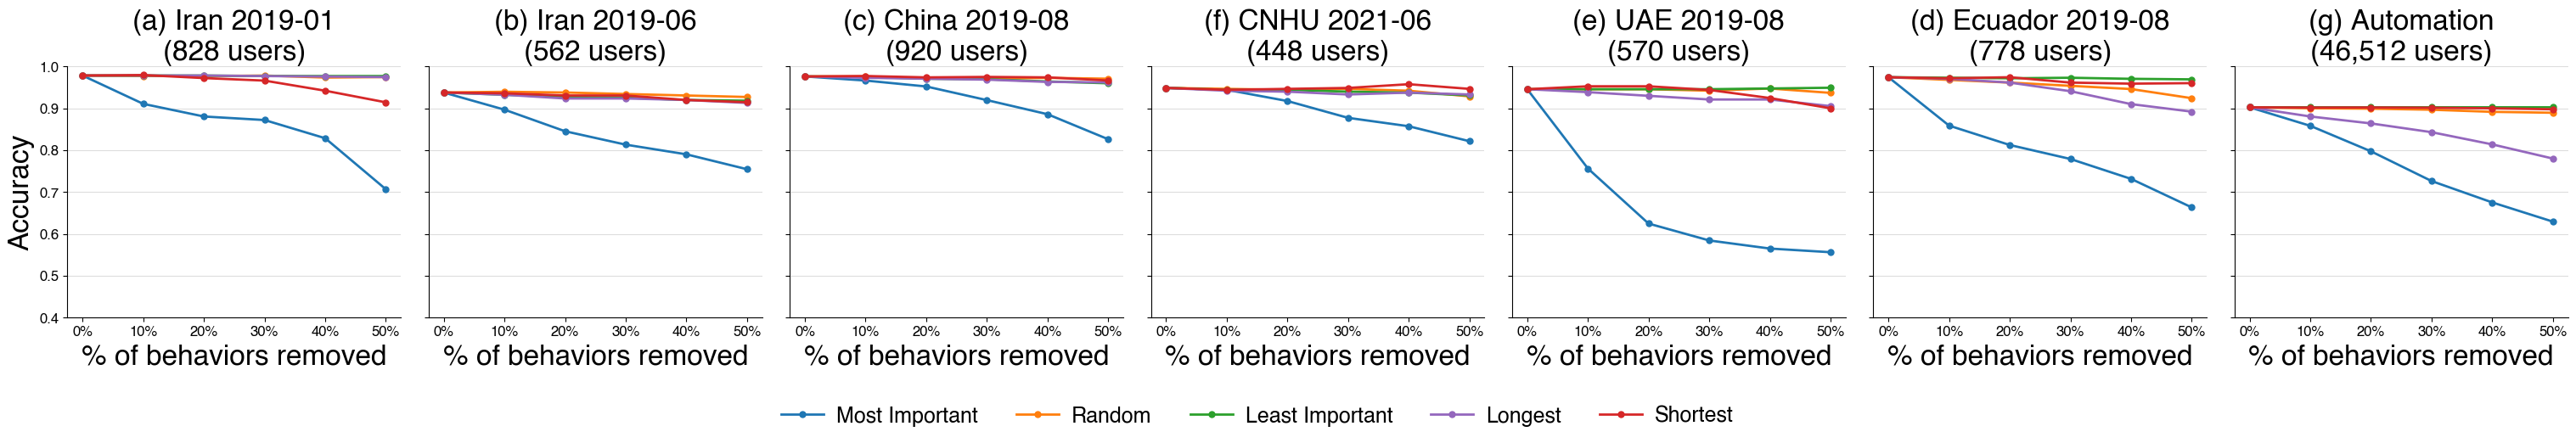


One-vs-rest accuracy: human / control
experiment           method           0%      10%     20%     30%     40%     50%   
-------------------  ---------------  ------  ------  ------  ------  ------  ------
(a) Iran 2019-01     Most Important   97.83%  91.06%  88.04%  87.20%  82.85%  70.65%
(a) Iran 2019-01     Random           97.83%  97.71%  97.71%  97.83%  97.34%  97.46%
(a) Iran 2019-01     Least Important  97.83%  97.83%  97.83%  97.71%  97.71%  97.71%
(a) Iran 2019-01     Longest          97.83%  97.83%  97.83%  97.71%  97.58%  97.46%
(a) Iran 2019-01     Shortest         97.83%  97.95%  97.22%  96.62%  94.20%  91.43%
(b) Iran 2019-06     Most Important   93.77%  89.68%  84.52%  81.32%  79.00%  75.44%
(b) Iran 2019-06     Random           93.77%  93.95%  93.77%  93.42%  93.06%  92.70%
(b) Iran 2019-06     Least Important  93.77%  93.24%  92.70%  92.53%  91.99%  91.81%
(b) Iran 2019-06     Longest          93.77%  93.24%  92.35%  92.35%  91.99%  91.28%
(b) Iran 2019-06     Short

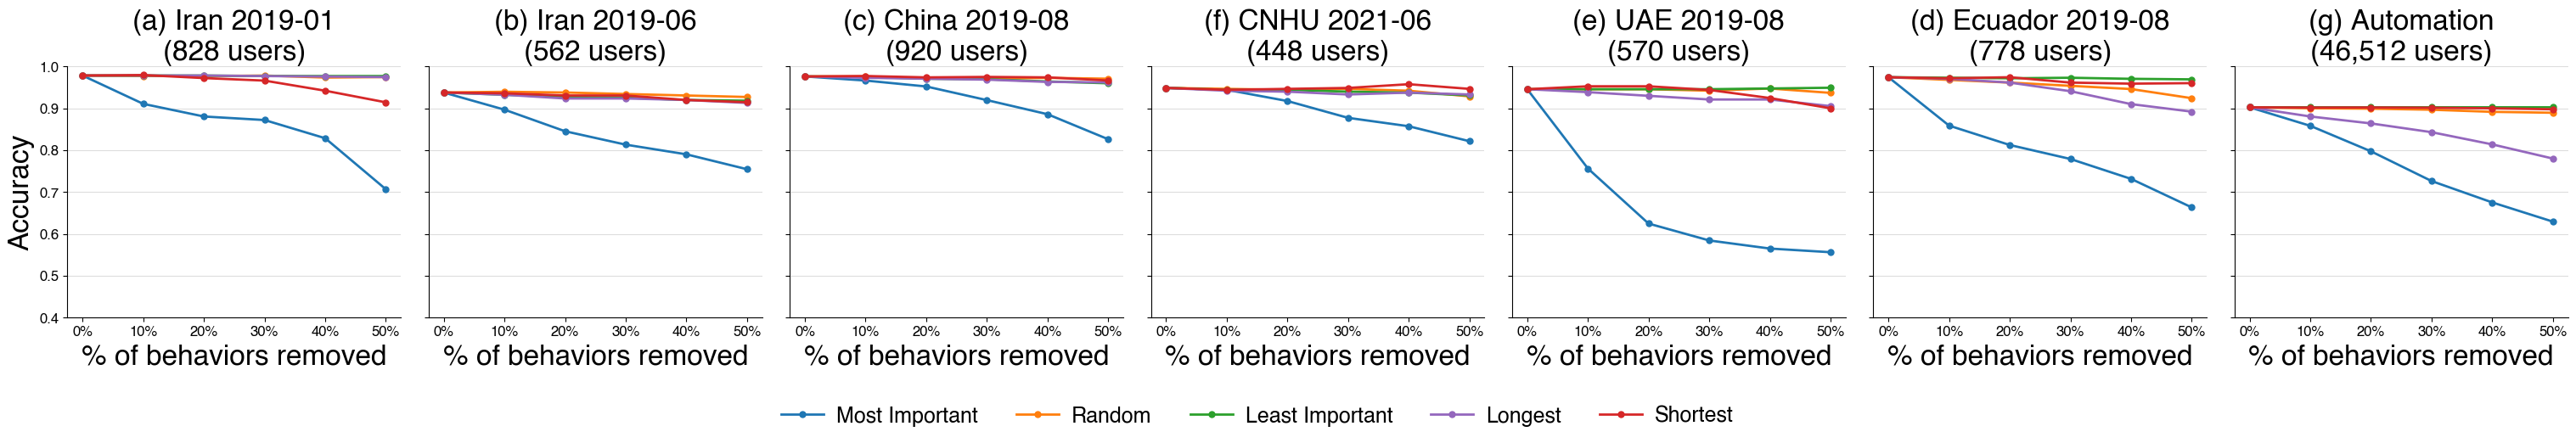


Accuracy: overall
experiment           method           0%      10%     20%     30%     40%     50%   
-------------------  ---------------  ------  ------  ------  ------  ------  ------
(a) Iran 2019-01     Most Important   97.83%  91.06%  88.04%  87.20%  82.85%  70.65%
(a) Iran 2019-01     Random           97.83%  97.71%  97.71%  97.83%  97.34%  97.46%
(a) Iran 2019-01     Least Important  97.83%  97.83%  97.83%  97.71%  97.71%  97.71%
(a) Iran 2019-01     Longest          97.83%  97.83%  97.83%  97.71%  97.58%  97.46%
(a) Iran 2019-01     Shortest         97.83%  97.95%  97.22%  96.62%  94.20%  91.43%
(b) Iran 2019-06     Most Important   93.77%  89.68%  84.52%  81.32%  79.00%  75.44%
(b) Iran 2019-06     Random           93.77%  93.95%  93.77%  93.42%  93.06%  92.70%
(b) Iran 2019-06     Least Important  93.77%  93.24%  92.70%  92.53%  91.99%  91.81%
(b) Iran 2019-06     Longest          93.77%  93.24%  92.35%  92.35%  91.99%  91.28%
(b) Iran 2019-06     Shortest         93.77%  

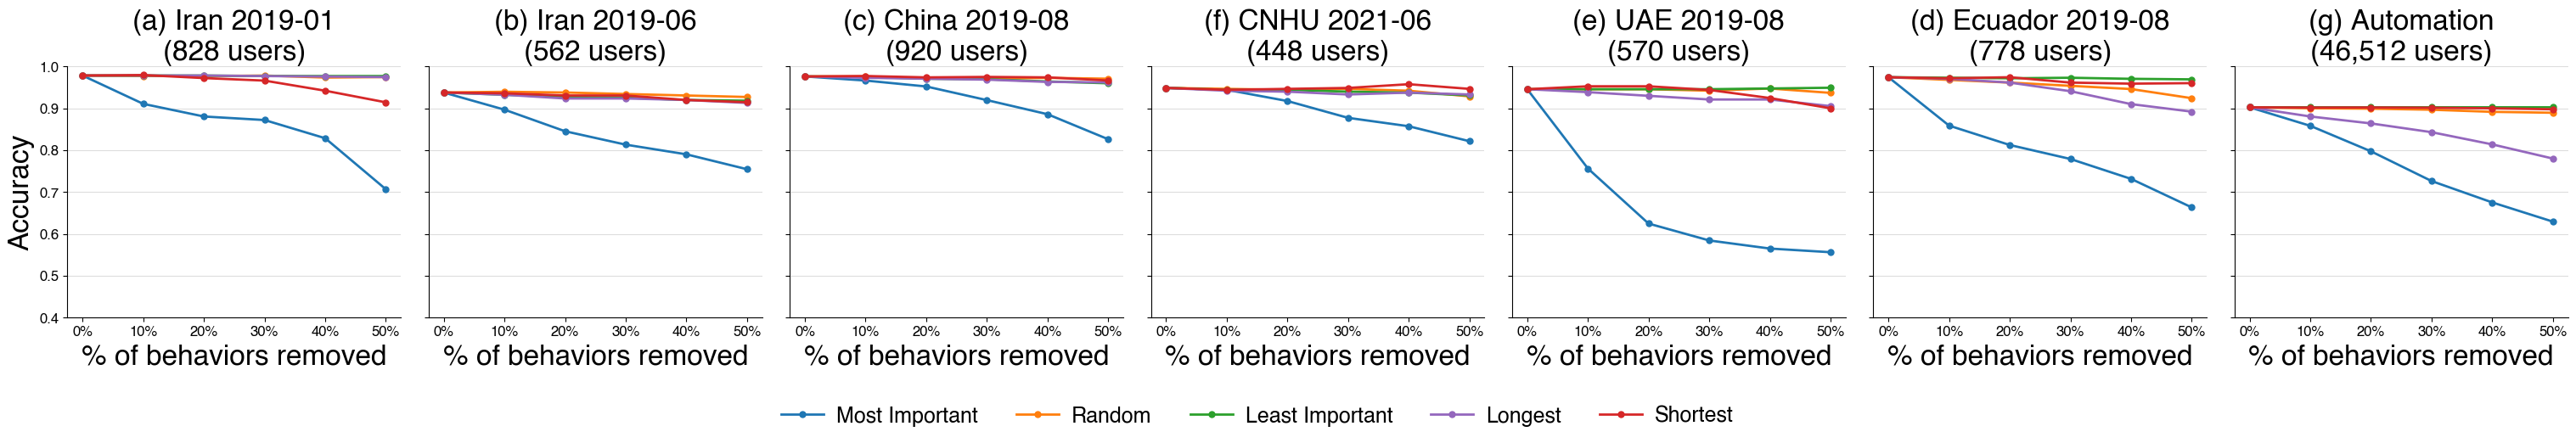


Precision: bot / driver
experiment           method           0%      10%      20%      30%      40%      50%    
-------------------  ---------------  ------  -------  -------  -------  -------  -------
(a) Iran 2019-01     Most Important   99.25%  100.00%  100.00%  100.00%  100.00%  100.00%
(a) Iran 2019-01     Random           99.25%  99.25%   99.50%   99.25%   99.25%   99.50% 
(a) Iran 2019-01     Least Important  99.25%  99.25%   99.25%   99.01%   98.77%   98.77% 
(a) Iran 2019-01     Longest          99.25%  99.25%   99.25%   99.01%   99.00%   99.00% 
(a) Iran 2019-01     Shortest         99.25%  100.00%  100.00%  100.00%  100.00%  100.00%
(b) Iran 2019-06     Most Important   95.56%  97.45%   98.02%   98.35%   99.39%   100.00%
(b) Iran 2019-06     Random           95.56%  95.91%   95.90%   95.52%   94.81%   94.78% 
(b) Iran 2019-06     Least Important  95.56%  94.18%   92.86%   92.23%   91.26%   90.38% 
(b) Iran 2019-06     Longest          95.56%  94.51%   93.43%   93.43%   92

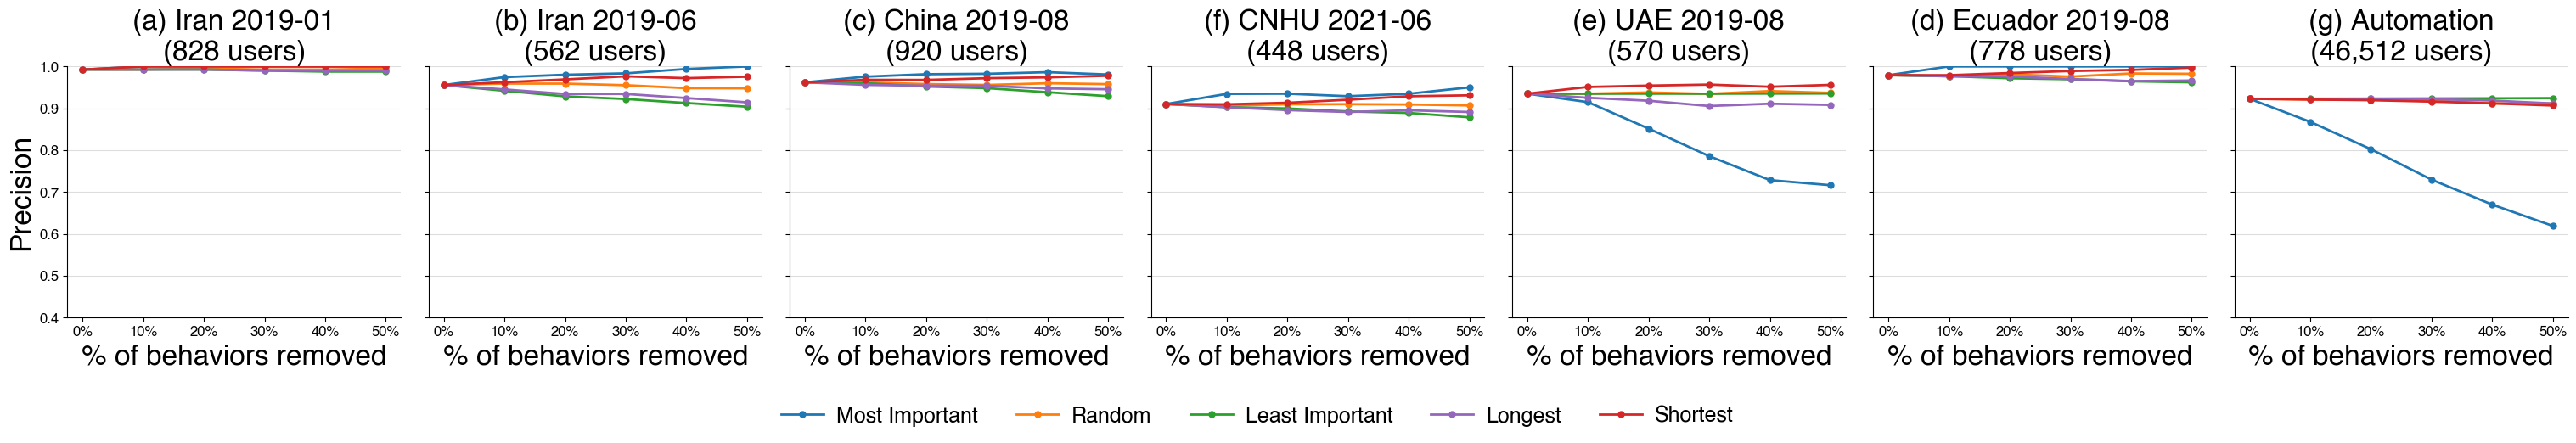


Precision: human / control
experiment           method           0%      10%     20%      30%      40%      50%    
-------------------  ---------------  ------  ------  -------  -------  -------  -------
(a) Iran 2019-01     Most Important   96.48%  84.84%  80.70%   79.62%   74.46%   63.01% 
(a) Iran 2019-01     Random           96.48%  96.25%  96.04%   96.48%   95.58%   95.59% 
(a) Iran 2019-01     Least Important  96.48%  96.48%  96.48%   96.47%   96.69%   96.69% 
(a) Iran 2019-01     Longest          96.48%  96.48%  96.48%   96.47%   96.24%   96.02% 
(a) Iran 2019-01     Shortest         96.48%  96.06%  94.74%   93.67%   89.61%   85.36% 
(b) Iran 2019-06     Most Important   92.12%  84.10%  76.94%   73.16%   70.53%   67.06% 
(b) Iran 2019-06     Random           92.12%  92.15%  91.84%   91.50%   91.44%   90.82% 
(b) Iran 2019-06     Least Important  92.12%  92.33%  92.55%   92.83%   92.75%   93.36% 
(b) Iran 2019-06     Longest          92.12%  92.04%  91.32%   91.32%   91.55%   9

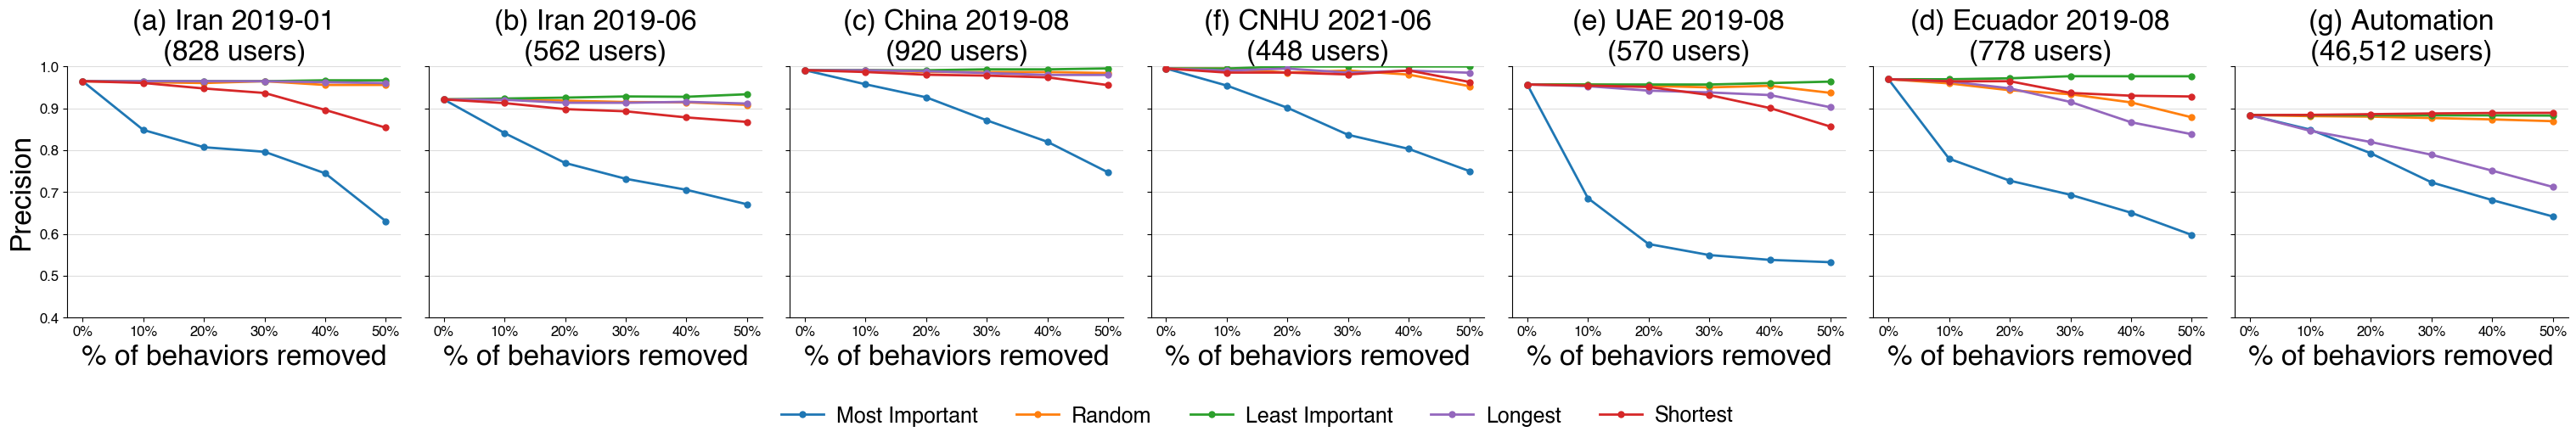


Precision: macro average
experiment           method           0%      10%     20%     30%     40%     50%   
-------------------  ---------------  ------  ------  ------  ------  ------  ------
(a) Iran 2019-01     Most Important   97.87%  92.42%  90.35%  89.81%  87.23%  81.51%
(a) Iran 2019-01     Random           97.87%  97.75%  97.77%  97.87%  97.41%  97.54%
(a) Iran 2019-01     Least Important  97.87%  97.87%  97.87%  97.74%  97.73%  97.73%
(a) Iran 2019-01     Longest          97.87%  97.87%  97.87%  97.74%  97.62%  97.51%
(a) Iran 2019-01     Shortest         97.87%  98.03%  97.37%  96.83%  94.81%  92.68%
(b) Iran 2019-06     Most Important   93.84%  90.77%  87.48%  85.75%  84.96%  83.53%
(b) Iran 2019-06     Random           93.84%  94.03%  93.87%  93.51%  93.13%  92.80%
(b) Iran 2019-06     Least Important  93.84%  93.26%  92.71%  92.53%  92.01%  91.87%
(b) Iran 2019-06     Longest          93.84%  93.27%  92.38%  92.38%  92.00%  91.28%
(b) Iran 2019-06     Shortest         9

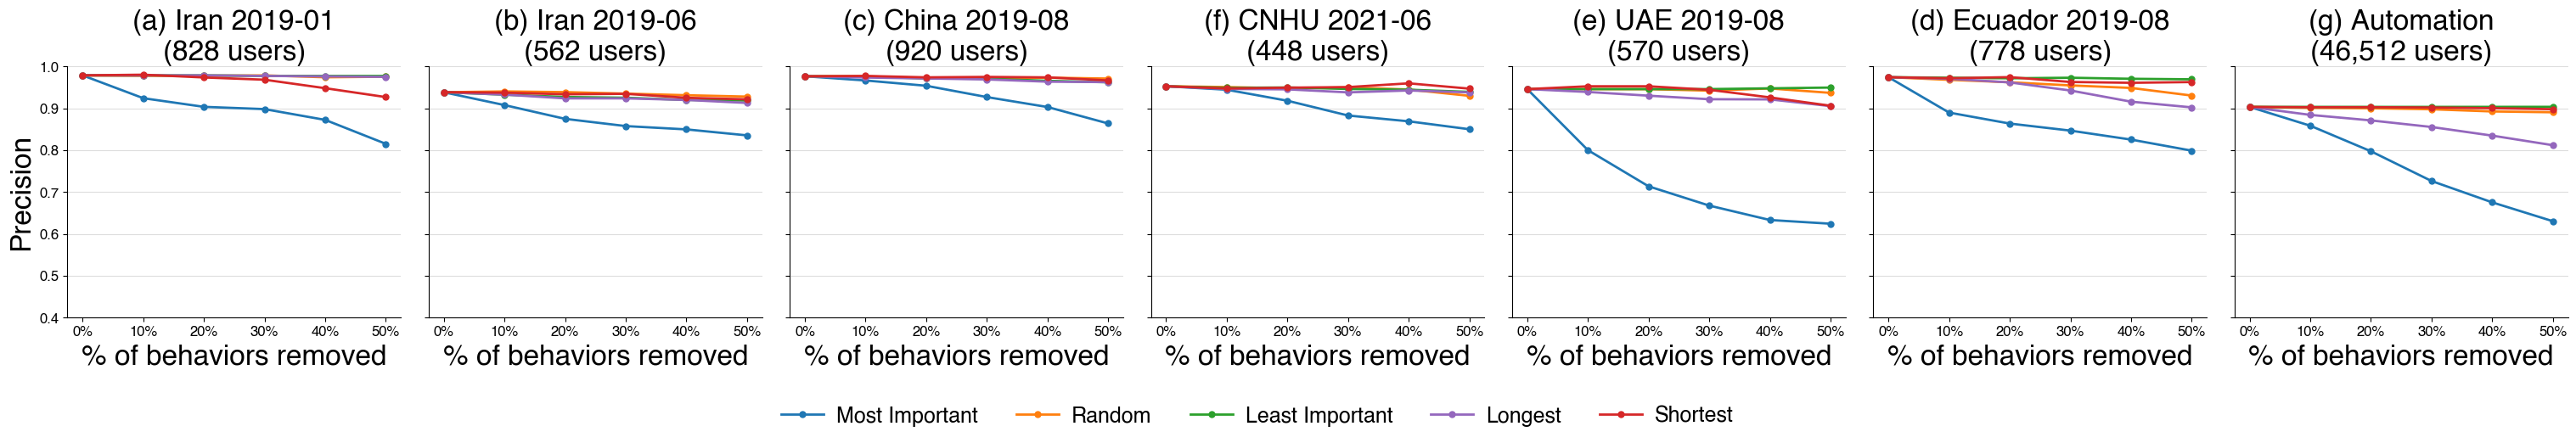


Recall: bot / driver
experiment           method           0%      10%     20%      30%      40%      50%    
-------------------  ---------------  ------  ------  -------  -------  -------  -------
(a) Iran 2019-01     Most Important   96.38%  82.13%  76.09%   74.40%   65.70%   41.30% 
(a) Iran 2019-01     Random           96.38%  96.14%  95.89%   96.38%   95.41%   95.41% 
(a) Iran 2019-01     Least Important  96.38%  96.38%  96.38%   96.38%   96.62%   96.62% 
(a) Iran 2019-01     Longest          96.38%  96.38%  96.38%   96.38%   96.14%   95.89% 
(a) Iran 2019-01     Shortest         96.38%  95.89%  94.44%   93.24%   88.41%   82.85% 
(b) Iran 2019-06     Most Important   91.81%  81.49%  70.46%   63.70%   58.36%   50.89% 
(b) Iran 2019-06     Random           91.81%  91.81%  91.46%   91.10%   91.10%   90.39% 
(b) Iran 2019-06     Least Important  91.81%  92.17%  92.53%   92.88%   92.88%   93.59% 
(b) Iran 2019-06     Longest          91.81%  91.81%  91.10%   91.10%   91.46%   91.10% 

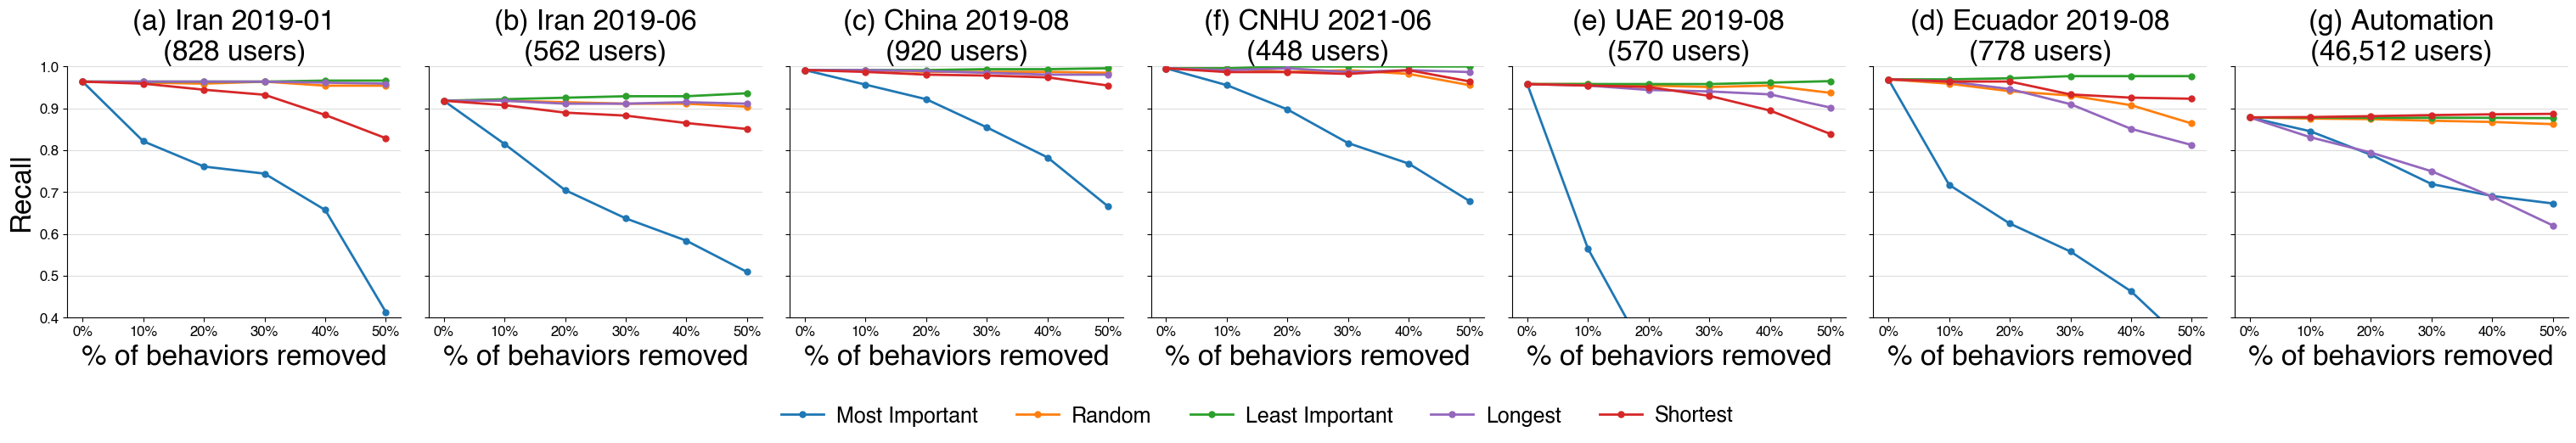


Recall: human / control
experiment           method           0%      10%      20%      30%      40%      50%    
-------------------  ---------------  ------  -------  -------  -------  -------  -------
(a) Iran 2019-01     Most Important   99.28%  100.00%  100.00%  100.00%  100.00%  100.00%
(a) Iran 2019-01     Random           99.28%  99.28%   99.52%   99.28%   99.28%   99.52% 
(a) Iran 2019-01     Least Important  99.28%  99.28%   99.28%   99.03%   98.79%   98.79% 
(a) Iran 2019-01     Longest          99.28%  99.28%   99.28%   99.03%   99.03%   99.03% 
(a) Iran 2019-01     Shortest         99.28%  100.00%  100.00%  100.00%  100.00%  100.00%
(b) Iran 2019-06     Most Important   95.73%  97.86%   98.58%   98.93%   99.64%   100.00%
(b) Iran 2019-06     Random           95.73%  96.09%   96.09%   95.73%   95.02%   95.02% 
(b) Iran 2019-06     Least Important  95.73%  94.31%   92.88%   92.17%   91.10%   90.04% 
(b) Iran 2019-06     Longest          95.73%  94.66%   93.59%   93.59%   92

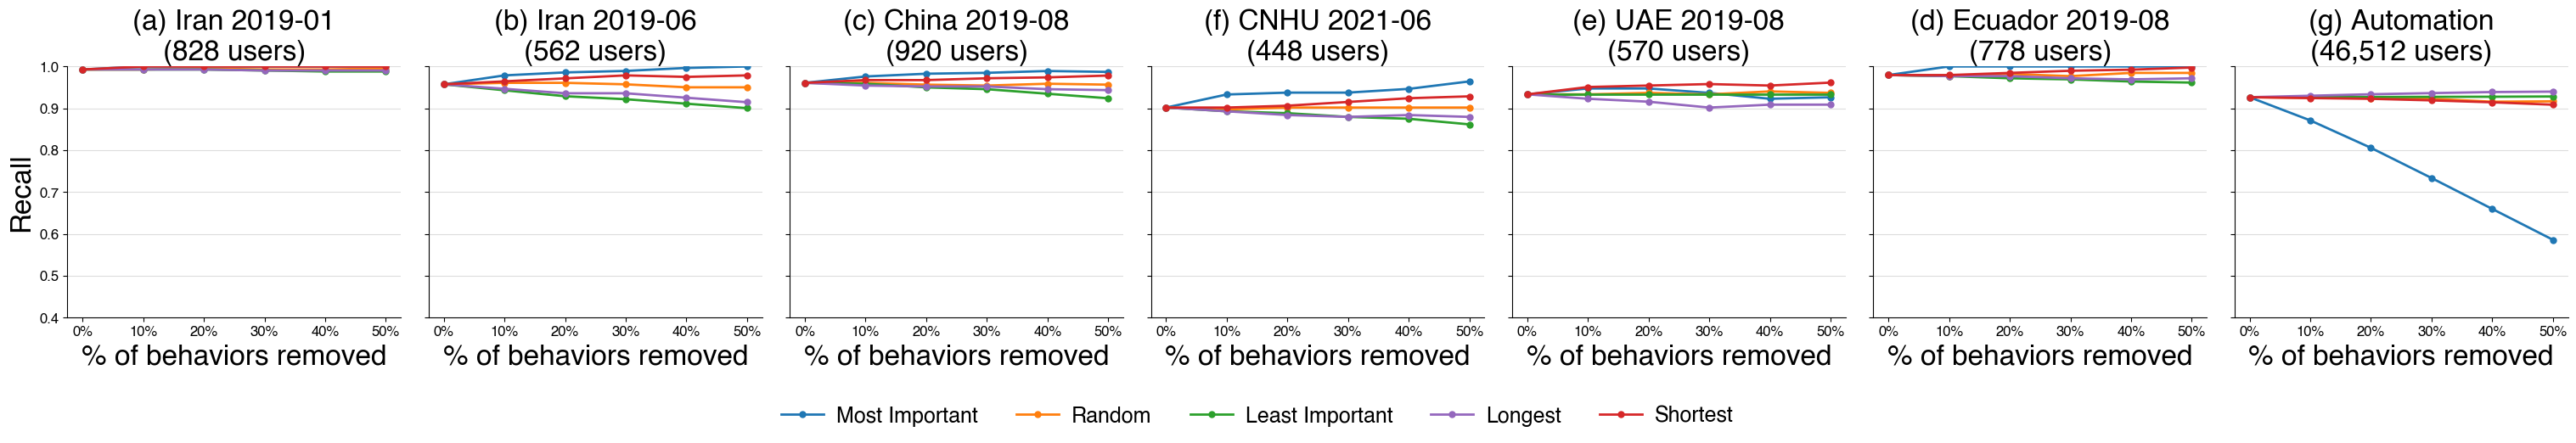


Recall: macro average
experiment           method           0%      10%     20%     30%     40%     50%   
-------------------  ---------------  ------  ------  ------  ------  ------  ------
(a) Iran 2019-01     Most Important   97.83%  91.06%  88.04%  87.20%  82.85%  70.65%
(a) Iran 2019-01     Random           97.83%  97.71%  97.71%  97.83%  97.34%  97.46%
(a) Iran 2019-01     Least Important  97.83%  97.83%  97.83%  97.71%  97.71%  97.71%
(a) Iran 2019-01     Longest          97.83%  97.83%  97.83%  97.71%  97.58%  97.46%
(a) Iran 2019-01     Shortest         97.83%  97.95%  97.22%  96.62%  94.20%  91.43%
(b) Iran 2019-06     Most Important   93.77%  89.68%  84.52%  81.32%  79.00%  75.44%
(b) Iran 2019-06     Random           93.77%  93.95%  93.77%  93.42%  93.06%  92.70%
(b) Iran 2019-06     Least Important  93.77%  93.24%  92.70%  92.53%  91.99%  91.81%
(b) Iran 2019-06     Longest          93.77%  93.24%  92.35%  92.35%  91.99%  91.28%
(b) Iran 2019-06     Shortest         93.7

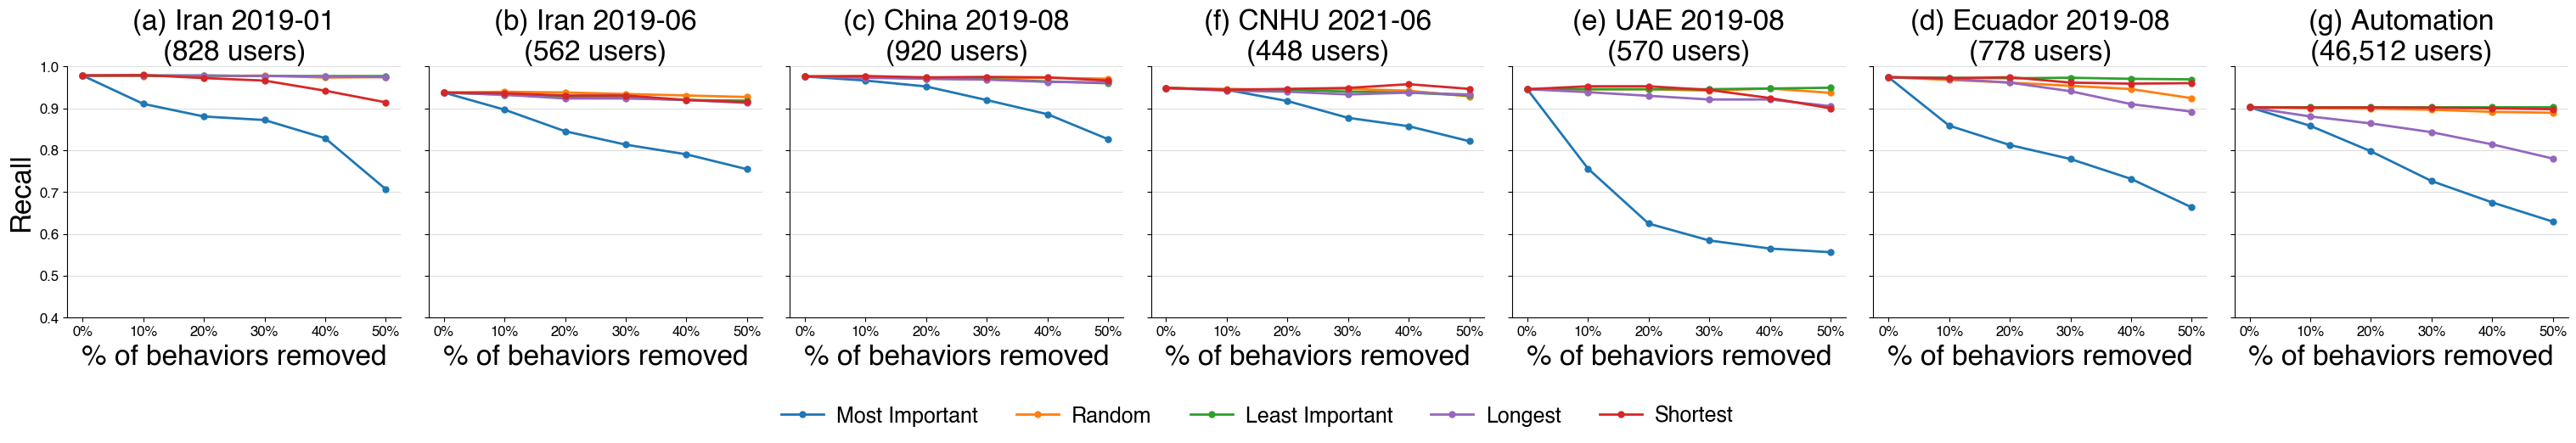


F1: bot / driver
experiment           method           0%      10%     20%     30%     40%     50%   
-------------------  ---------------  ------  ------  ------  ------  ------  ------
(a) Iran 2019-01     Most Important   97.79%  90.19%  86.42%  85.32%  79.30%  58.46%
(a) Iran 2019-01     Random           97.79%  97.67%  97.66%  97.79%  97.29%  97.41%
(a) Iran 2019-01     Least Important  97.79%  97.79%  97.79%  97.67%  97.68%  97.68%
(a) Iran 2019-01     Longest          97.79%  97.79%  97.79%  97.67%  97.55%  97.42%
(a) Iran 2019-01     Shortest         97.79%  97.90%  97.14%  96.50%  93.85%  90.62%
(b) Iran 2019-06     Most Important   93.65%  88.76%  81.99%  77.32%  73.54%  67.45%
(b) Iran 2019-06     Random           93.65%  93.82%  93.62%  93.26%  92.92%  92.53%
(b) Iran 2019-06     Least Important  93.65%  93.17%  92.69%  92.55%  92.06%  91.96%
(b) Iran 2019-06     Longest          93.65%  93.14%  92.25%  92.25%  91.95%  91.27%
(b) Iran 2019-06     Shortest         93.65%  9

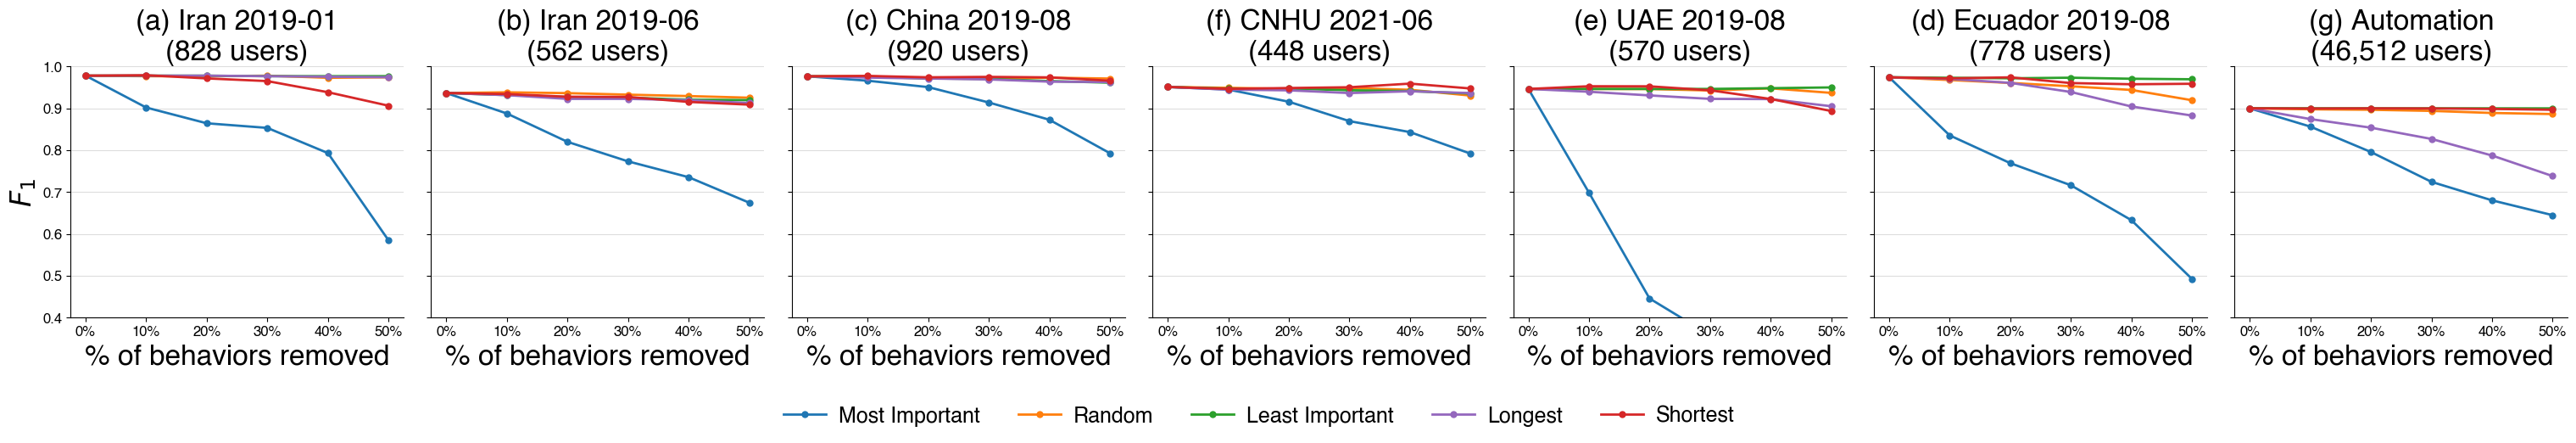


F1: human / control
experiment           method           0%      10%     20%     30%     40%     50%   
-------------------  ---------------  ------  ------  ------  ------  ------  ------
(a) Iran 2019-01     Most Important   97.86%  91.80%  89.32%  88.65%  85.36%  77.31%
(a) Iran 2019-01     Random           97.86%  97.74%  97.75%  97.86%  97.39%  97.51%
(a) Iran 2019-01     Least Important  97.86%  97.86%  97.86%  97.74%  97.73%  97.73%
(a) Iran 2019-01     Longest          97.86%  97.86%  97.86%  97.74%  97.62%  97.50%
(a) Iran 2019-01     Shortest         97.86%  97.99%  97.30%  96.73%  94.52%  92.10%
(b) Iran 2019-06     Most Important   93.89%  90.46%  86.43%  84.11%  82.60%  80.29%
(b) Iran 2019-06     Random           93.89%  94.08%  93.91%  93.57%  93.19%  92.87%
(b) Iran 2019-06     Least Important  93.89%  93.31%  92.72%  92.50%  91.92%  91.67%
(b) Iran 2019-06     Longest          93.89%  93.33%  92.44%  92.44%  92.04%  91.30%
(b) Iran 2019-06     Shortest         93.89%

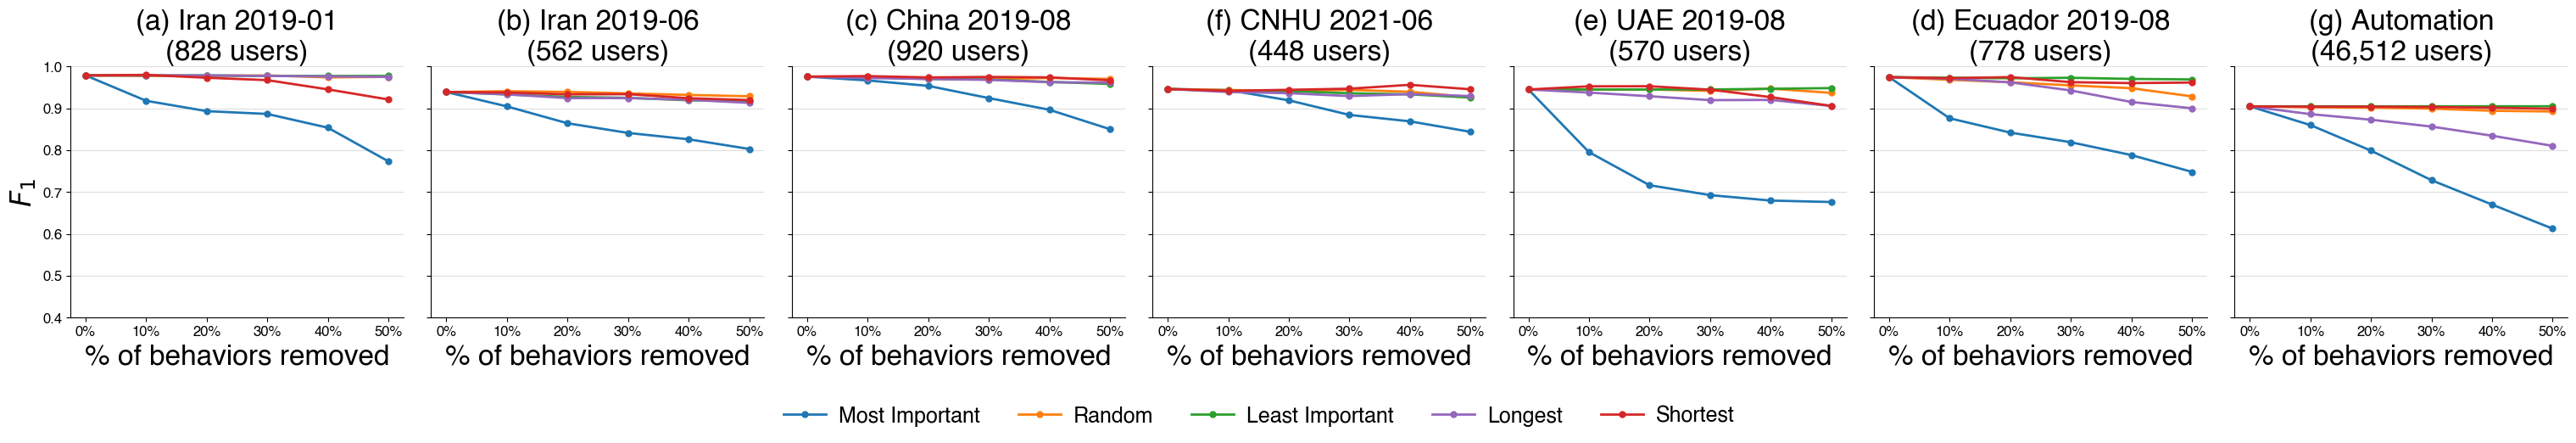


F1: macro average
experiment           method           0%      10%     20%     30%     40%     50%   
-------------------  ---------------  ------  ------  ------  ------  ------  ------
(a) Iran 2019-01     Most Important   97.83%  90.99%  87.87%  86.98%  82.33%  67.89%
(a) Iran 2019-01     Random           97.83%  97.70%  97.70%  97.83%  97.34%  97.46%
(a) Iran 2019-01     Least Important  97.83%  97.83%  97.83%  97.70%  97.71%  97.71%
(a) Iran 2019-01     Longest          97.83%  97.83%  97.83%  97.70%  97.58%  97.46%
(a) Iran 2019-01     Shortest         97.83%  97.95%  97.22%  96.61%  94.18%  91.36%
(b) Iran 2019-06     Most Important   93.77%  89.61%  84.21%  80.72%  78.07%  73.87%
(b) Iran 2019-06     Random           93.77%  93.95%  93.77%  93.41%  93.06%  92.70%
(b) Iran 2019-06     Least Important  93.77%  93.24%  92.70%  92.53%  91.99%  91.81%
(b) Iran 2019-06     Longest          93.77%  93.24%  92.35%  92.35%  91.99%  91.28%
(b) Iran 2019-06     Shortest         93.77%  

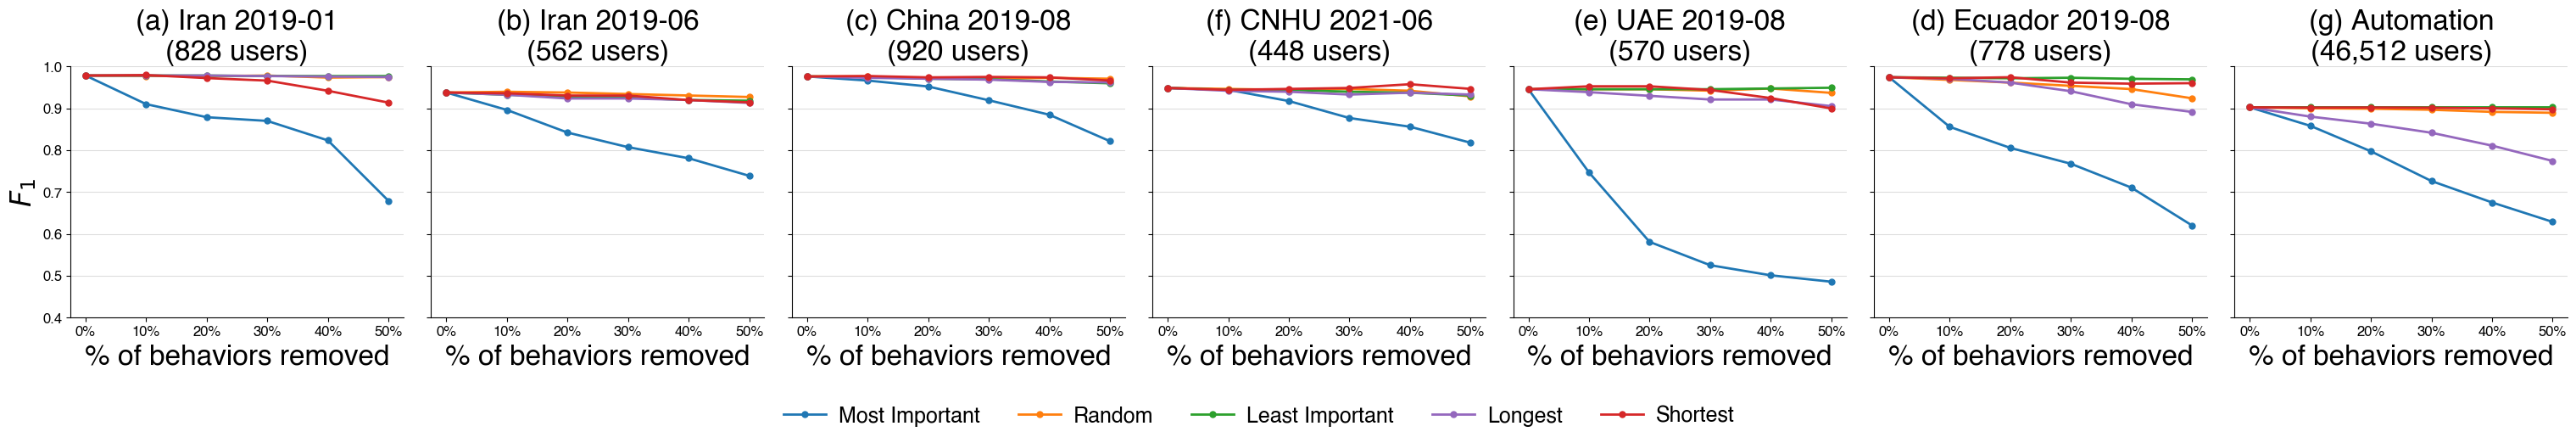

In [5]:
PLOTS = [
    ("One-vs-rest accuracy: bot / driver", "accuracy_positive", "Accuracy", "accuracy_positive.png"),
    ("One-vs-rest accuracy: human / control", "accuracy_negative", "Accuracy", "accuracy_negative.png"),
    ("Accuracy: overall", "accuracy", "Accuracy", "accuracy_overall.png"),
    ("Precision: bot / driver", "precision_positive", "Precision", "precision_positive.png"),
    ("Precision: human / control", "precision_negative", "Precision", "precision_negative.png"),
    ("Precision: macro average", "precision_macro", "Precision", "precision_macro.png"),
    ("Recall: bot / driver", "recall_positive", "Recall", "recall_positive.png"),
    ("Recall: human / control", "recall_negative", "Recall", "recall_negative.png"),
    ("Recall: macro average", "recall_macro", "Recall", "recall_macro.png"),
    ("F1: bot / driver", "f1_positive", r"$F_1$", "f1_positive.png"),
    ("F1: human / control", "f1_negative", r"$F_1$", "f1_negative.png"),
    ("F1: macro average", "f1_macro", r"$F_1$", "f1_macro.png"),
]

for title, metric_field, y_label, filename in PLOTS:
    plot_metric_grid(title, metric_field, y_label, filename)
    plt.show()